# EDA for Data Section Slides

Generates presentation-ready visualizations covering:
1. Dataset characteristics & target distribution
2. PEAD signal confirmation (Beat vs Miss drift profile)
3. Feature correlation analysis & dimensionality insights
4. Missing value patterns
5. Sector analysis & feature family breakdown

**Output:** PNG files in `figures/` directory

In [3]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from bisect import bisect_left
from itertools import combinations
import os, warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.facecolor'] = '#F5F6FA'
plt.rcParams['axes.facecolor'] = '#F5F6FA'
plt.rcParams['font.size'] = 11
NAVY, GOLD = '#1E3A6E', '#D9A441'
RED = '#B23A2E'
GREEN = '#2E7D32'

OUTPUT_DIR = 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Figures will be saved to {OUTPUT_DIR}/')

Figures will be saved to figures/


---
## 1. Data Loading & Merge
Build the full modeling table (257 features) from source staging files.

In [11]:


df_tech = pl.read_parquet("../data/model_staging/tech_modeling_table.parquet")
print(f"Tech table shape: {df_tech.shape}")

df_fund = pl.read_parquet("../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet")
df_fund = df_fund.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin",     "gross_margin_qoq",
    "debt_to_equity",   "debt_to_equity_qoq",
    "fcf_margin",       "fcf_margin_qoq",
    "roe",              "roe_qoq",
    "surprisePercentage",
])

# Read FinBERT once, extract both sentiment and sector
df_finbert_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")

df_finbert = df_finbert_raw.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob",
])

df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet")
df_nz = df_nz.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])

df_model = df_tech.join(df_fund,     on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_nz,      on=["symbol", "earnings_date"], how="left")

# Sector one-hot (from same FinBERT parquet, no second read)
df_sector = df_finbert_raw.select(["symbol", "sector"]).unique()
df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
sectors = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")
df_model = df_model.join(df_sector, on="symbol", how="left")

# Drop CAR columns (not used in this model)
df_model = df_model.drop([
    col for col in df_model.columns if col.startswith("car")
])

print(f"Combined table shape: {df_model.shape}")
print(f"Target class distribution:\n{df_model['target_class'].value_counts().sort('target_class')}")

Tech table shape: (24048, 243)
Combined table shape: (24048, 270)
Target class distribution:
shape: (3, 2)
┌──────────────┬───────┐
│ target_class ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 0            ┆ 7955  │
│ 1            ┆ 6428  │
│ 2            ┆ 9665  │
└──────────────┴───────┘


In [12]:
# Compute 3-class target
df_model = df_model.with_columns(
    pl.when(pl.col('target_return') < 0.02).then(0)
    .when(pl.col('target_return') < 0.04).then(1)
    .otherwise(2)
    .alias('target_class')
).with_columns(
    (pl.col('surprisePercentage') > 0).cast(pl.Int8).alias('beat')
).with_columns(
    pl.col('earnings_date').dt.year().alias('year')
)

N = len(df_model)
class_dist = df_model['target_class'].value_counts().sort('target_class')
print('3-Class Target Distribution:')
shares = {}
labels = {0: 'Low (<2%)', 1: 'Moderate (2-4%)', 2: 'Strong (>=4%)'}
colors_cls = {0: '#999999', 1: GOLD, 2: GREEN}
for row in class_dist.iter_rows(named=True):
    pct = row['count'] / N * 100
    shares[row['target_class']] = pct
    print(f'  {labels[row["target_class"]]}: {row["count"]:>6} ({pct:.1f}%)')
print(f'  Beat rate: {df_model["beat"].mean():.1%}')
print(f'  Target return mean: {df_model["target_return"].mean():.2%}')

3-Class Target Distribution:
  Low (<2%):   7955 (33.1%)
  Moderate (2-4%):   6428 (26.7%)
  Strong (>=4%):   9665 (40.2%)
  Beat rate: 73.5%
  Target return mean: 4.30%


---
## 2. Target Distribution

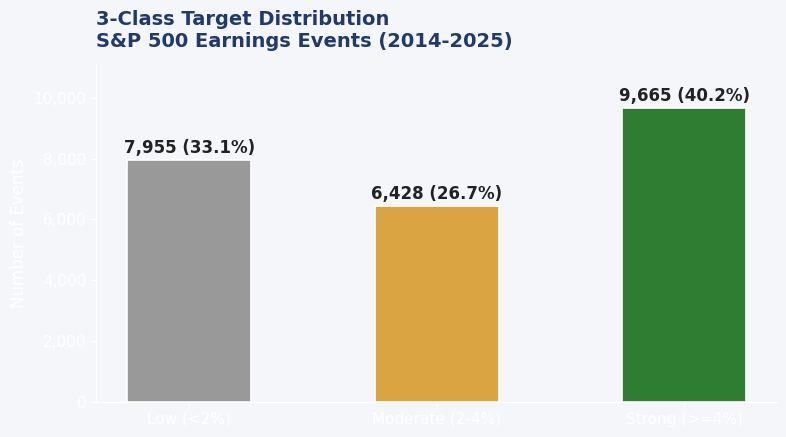

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))

class_order = [0, 1, 2]
counts = [class_dist.filter(pl.col('target_class') == i)['count'].item() for i in class_order]
bar_colors = [colors_cls[i] for i in class_order]
bar_labels = [labels[i] for i in class_order]

bars = ax.bar(bar_labels, counts, color=bar_colors, width=0.5, edgecolor='white', linewidth=1.2, zorder=3)

for bar, count in zip(bars, counts):
    pct = count / N * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + N * 0.01,
            f'{count:,} ({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold', color='#222')

ax.set_ylabel('Number of Events', fontsize=12)
ax.set_title('3-Class Target Distribution\nS&P 500 Earnings Events (2014-2025)',
             fontsize=14, fontweight='bold', color=NAVY, loc='left', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.margins(y=0.15)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/target_class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'

Overall class distribution:
shape: (3, 2)
┌──────┬───────┐
│ beat ┆ len   │
│ ---  ┆ ---   │
│ i8   ┆ u32   │
╞══════╪═══════╡
│ null ┆ 88    │
│ 0    ┆ 6115  │
│ 1    ┆ 16903 │
└──────┴───────┘

Overall beat rate: 73.4%


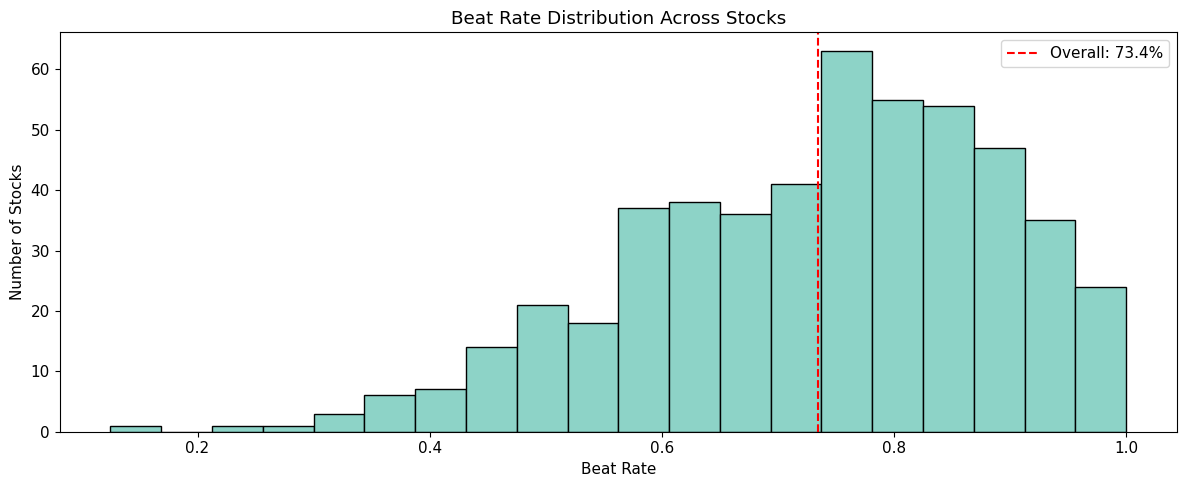

In [6]:
# Class balance — using beat column from pipeline
beat_dist = df_model.group_by("beat").len().sort("beat")
print("Overall class distribution:")
print(beat_dist)

beat_rate = df_model["beat"].mean()
print(f"\nOverall beat rate: {beat_rate:.1%}")

# Beat rate by symbol (check for per-stock imbalance)
per_stock = df_model.group_by("symbol").agg([
    pl.col("beat").mean().alias("beat_rate"),
    pl.len().alias("events"),
]).sort("beat_rate")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(per_stock["beat_rate"].to_list(), bins=20, edgecolor="black")
ax.axvline(x=beat_rate, color="red", linestyle="--", label=f"Overall: {beat_rate:.1%}")
ax.set_title("Beat Rate Distribution Across Stocks")
ax.set_xlabel("Beat Rate")
ax.set_ylabel("Number of Stocks")
ax.legend()
plt.tight_layout()
plt.show()

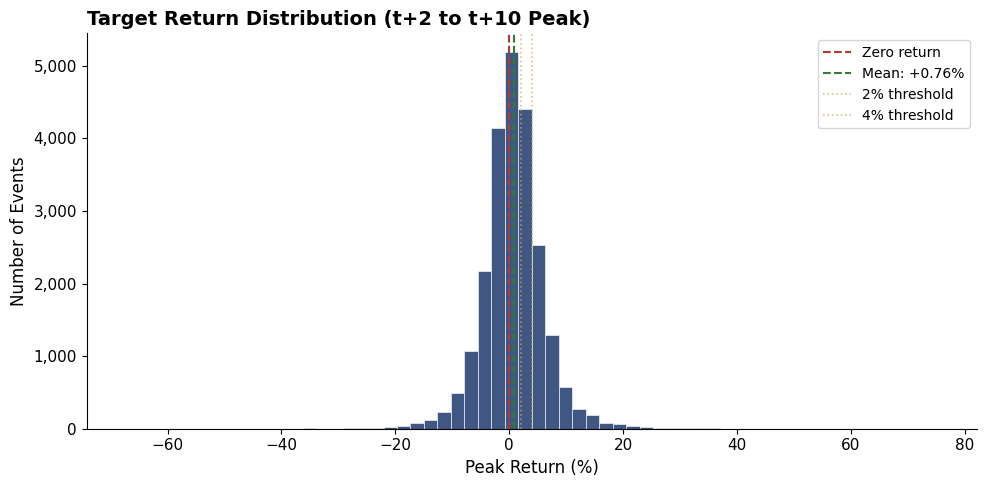

In [7]:
import matplotlib.ticker as mticker

target_data = df_model["target_return"].drop_nulls() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(target_data.to_list(), bins=60, color='#1E3A6E', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(x=0, color='#B23A2E', linestyle='--', linewidth=1.5, label='Zero return')
ax.axvline(x=float(target_data.mean()), color='#2E7D32', linestyle='--', linewidth=1.5,
           label=f'Mean: {float(target_data.mean()):+.2f}%')
ax.axvline(x=2.0, color='#D9A441', linestyle=':', linewidth=1.2, alpha=0.7, label='2% threshold')
ax.axvline(x=4.0, color='#D9A441', linestyle=':', linewidth=1.2, alpha=0.7, label='4% threshold')

ax.set_xlabel('Peak Return (%)', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.set_title('Target Return Distribution (t+2 to t+10 Peak)', fontsize=14, fontweight='bold', loc='left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('target_return_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


Target return descriptive stats:
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ target_return │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 23106.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ 0.007648      │
│ std        ┆ 0.055747      │
│ min        ┆ -0.670921     │
│ 25%        ┆ -0.021398     │
│ 50%        ┆ 0.006958      │
│ 75%        ┆ 0.035595      │
│ max        ┆ 0.750633      │
└────────────┴───────────────┘


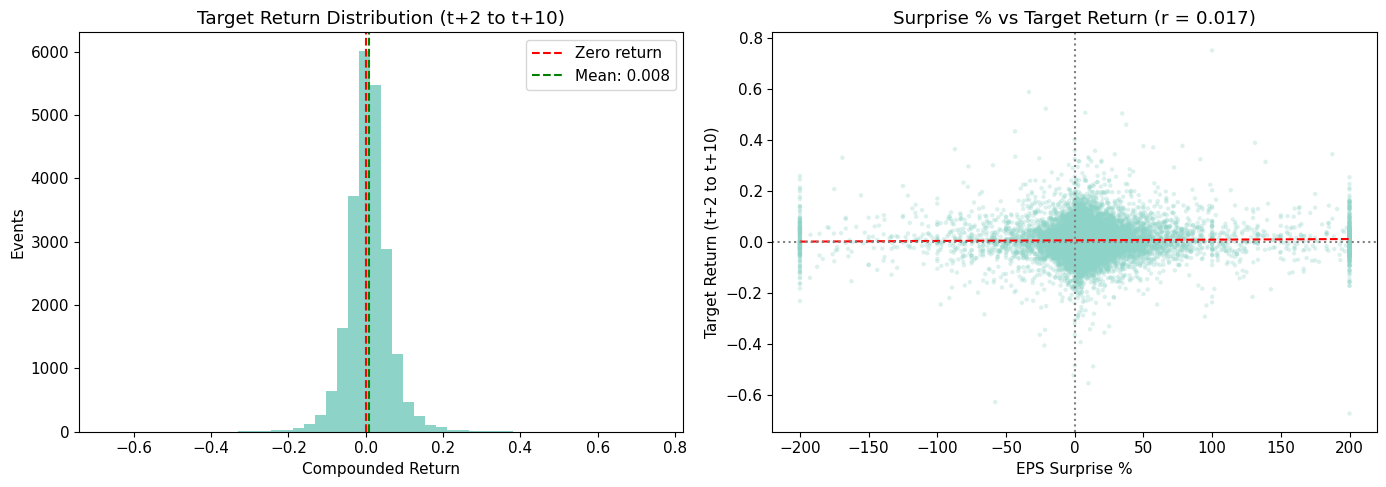

In [8]:
# Target return distribution
target_data = df_model["target_return"].drop_nulls()

print("\nTarget return descriptive stats:")
print(df_model.select("target_return").describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target_data.to_list(), bins=50, edgecolor="none")
axes[0].axvline(x=0, color="red", linestyle="--", label="Zero return")
axes[0].axvline(x=float(target_data.mean()), color="green", linestyle="--",
                label=f"Mean: {float(target_data.mean()):.3f}")
axes[0].set_title("Target Return Distribution (t+2 to t+10)")
axes[0].set_xlabel("Compounded Return")
axes[0].set_ylabel("Events")
axes[0].legend()

# Surprise vs target return scatter
scatter = df_model.select("surprisePercentage", "target_return").drop_nulls()
axes[1].scatter(scatter["surprisePercentage"].to_list(),
                scatter["target_return"].to_list(),
                alpha=0.3, s=10, edgecolors="none")
z = np.polyfit(scatter["surprisePercentage"].to_list(),
               scatter["target_return"].to_list(), 1)
x_line = np.linspace(scatter["surprisePercentage"].min(),
                     scatter["surprisePercentage"].max(), 100)
axes[1].plot(x_line, np.polyval(z, x_line), color="red", linestyle="--")
r_val = np.corrcoef(scatter["surprisePercentage"].to_list(),
                    scatter["target_return"].to_list())[0, 1]
axes[1].set_title(f"Surprise % vs Target Return (r = {r_val:.3f})")
axes[1].set_xlabel("EPS Surprise %")
axes[1].set_ylabel("Target Return (t+2 to t+10)")
axes[1].axhline(y=0, color="gray", linestyle=":")
axes[1].axvline(x=0, color="gray", linestyle=":")

plt.tight_layout()
plt.show()


Target return descriptive stats:
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ target_return │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 23106.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ 0.007648      │
│ std        ┆ 0.055747      │
│ min        ┆ -0.670921     │
│ 25%        ┆ -0.021398     │
│ 50%        ┆ 0.006958      │
│ 75%        ┆ 0.035595      │
│ max        ┆ 0.750633      │
└────────────┴───────────────┘


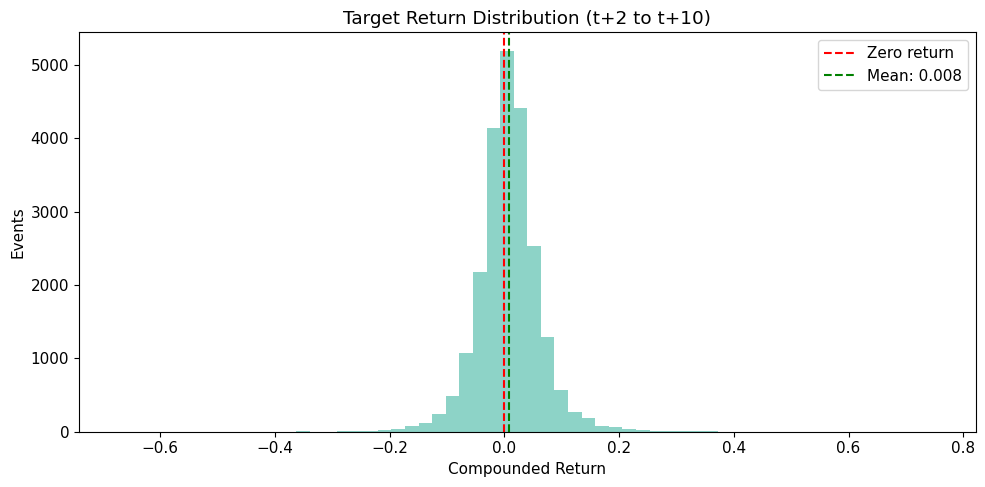

In [9]:
target_data = df_model["target_return"].drop_nulls()

print("\nTarget return descriptive stats:")
print(df_model.select("target_return").describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(target_data.to_list(), bins=60, edgecolor="none")
ax.axvline(x=0, color="red", linestyle="--", label="Zero return")
ax.axvline(x=float(target_data.mean()), color="green", linestyle="--",
           label=f"Mean: {float(target_data.mean()):.3f}")
ax.set_title("Target Return Distribution (t+2 to t+10)")
ax.set_xlabel("Compounded Return")
ax.set_ylabel("Events")
ax.legend()
plt.tight_layout()
plt.show()

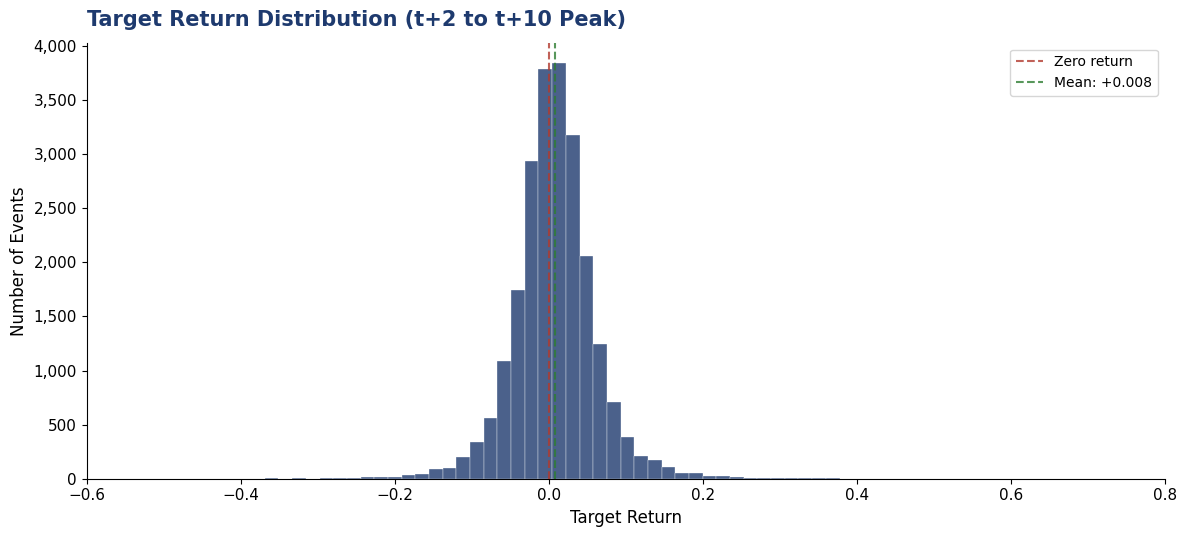

In [10]:
import matplotlib.ticker as mticker

target_data = df_model["target_return"].drop_nulls()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.hist(target_data.to_list(), bins=80, color='#1E3A6E', edgecolor='white', linewidth=0.3, alpha=0.8)

ax.axvline(x=0, color='#B23A2E', linestyle='--', linewidth=1.5, alpha=0.8, label='Zero return')
ax.axvline(x=float(target_data.mean()), color='#2E7D32', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'Mean: {float(target_data.mean()):+.3f}')

ax.set_xlim(-0.6, 0.8)
ax.set_xlabel('Target Return', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.set_title('Target Return Distribution (t+2 to t+10 Peak)', fontsize=15, fontweight='bold', color='#1E3A6E', loc='left', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig('target_return_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

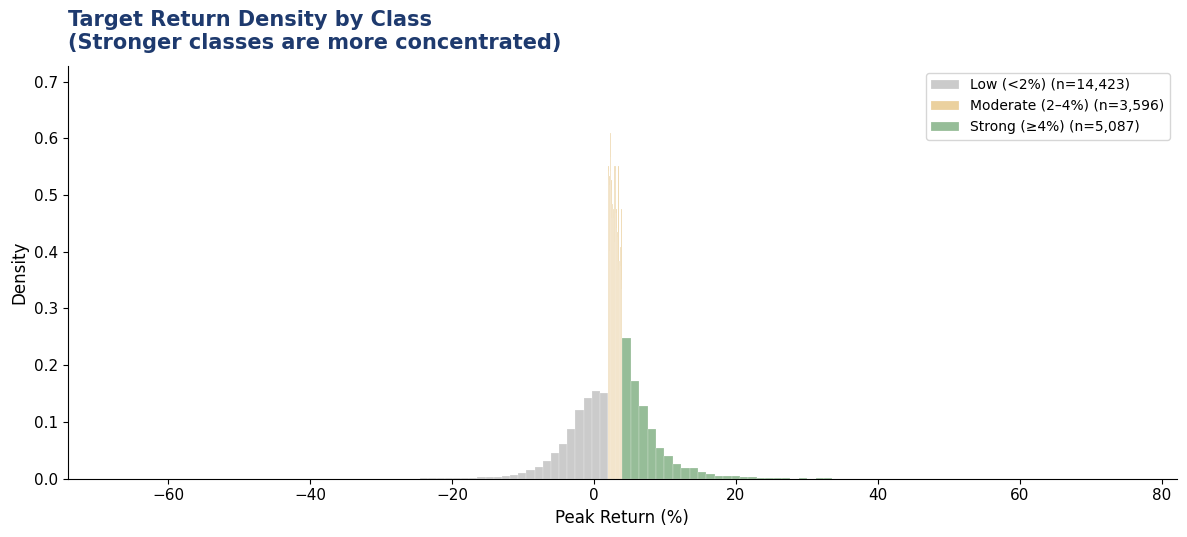

In [11]:
import matplotlib.ticker as mticker

pdf = df_model.select(['target_return', 'target_class']).to_pandas()
pdf['target_return_pct'] = pdf['target_return'] * 100

labels = {0: 'Low (<2%)', 1: 'Moderate (2–4%)', 2: 'Strong (≥4%)'}
colors = {0: '#999999', 1: '#D9A441', 2: '#2E7D32'}

fig, ax = plt.subplots(figsize=(12, 5.5))

for cls in [0, 1, 2]:
    data = pdf[pdf['target_class'] == cls]['target_return_pct']
    ax.hist(data, bins=60, color=colors[cls], alpha=0.5, edgecolor='white', linewidth=0.3,
            density=True, label=f'{labels[cls]} (n={len(data):,})')

ax.set_xlabel('Peak Return (%)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Target Return Density by Class\n(Stronger classes are more concentrated)', 
             fontsize=15, fontweight='bold', color='#1E3A6E', loc='left', pad=12)
ax.legend(fontsize=10, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

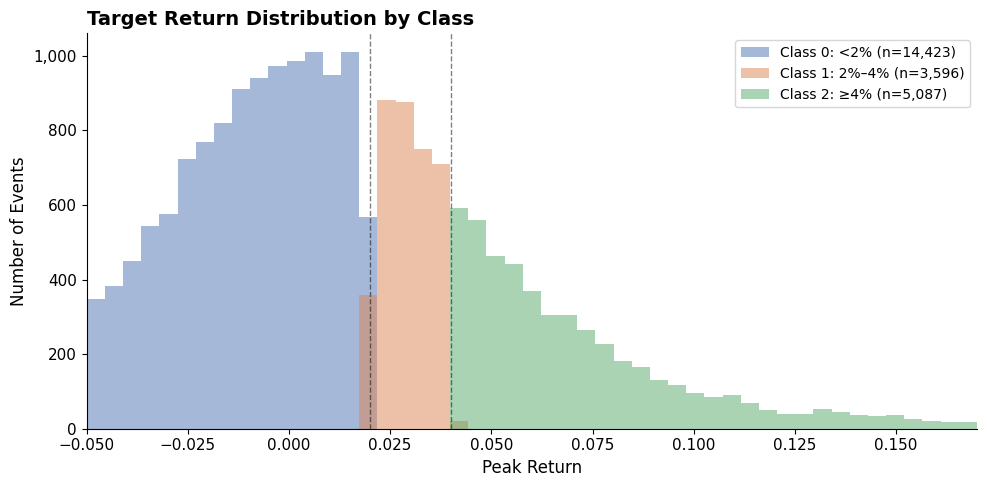

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

LOW_BOUND, HIGH_BOUND = 0.02, 0.04

class_colors = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}
class_labels = {
    0: f"Class 0: <{LOW_BOUND:.0%}",
    1: f"Class 1: {LOW_BOUND:.0%}\u2013{HIGH_BOUND:.0%}",
    2: f"Class 2: \u2265{HIGH_BOUND:.0%}",
}

pdf = df_model.select(['target_return', 'target_class']).to_pandas()

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(-0.05, 0.17, 50)

for cls in [0, 1, 2]:
    subset = pdf[pdf["target_class"] == cls]["target_return"]
    ax.hist(subset, bins=bins, color=class_colors[cls], alpha=0.5, 
            label=f'{class_labels[cls]} (n={len(subset):,})')

ax.axvline(LOW_BOUND, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axvline(HIGH_BOUND, color="black", linestyle="--", linewidth=1, alpha=0.5)

ax.set_xlim(-0.05, 0.17)
ax.set_xlabel("Peak Return", fontsize=12)
ax.set_ylabel("Number of Events", fontsize=12)
ax.set_title("Target Return Distribution by Class", fontsize=14, fontweight='bold', loc='left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig("figures/target_return_distribution.png", dpi=200, bbox_inches='tight')
plt.show()

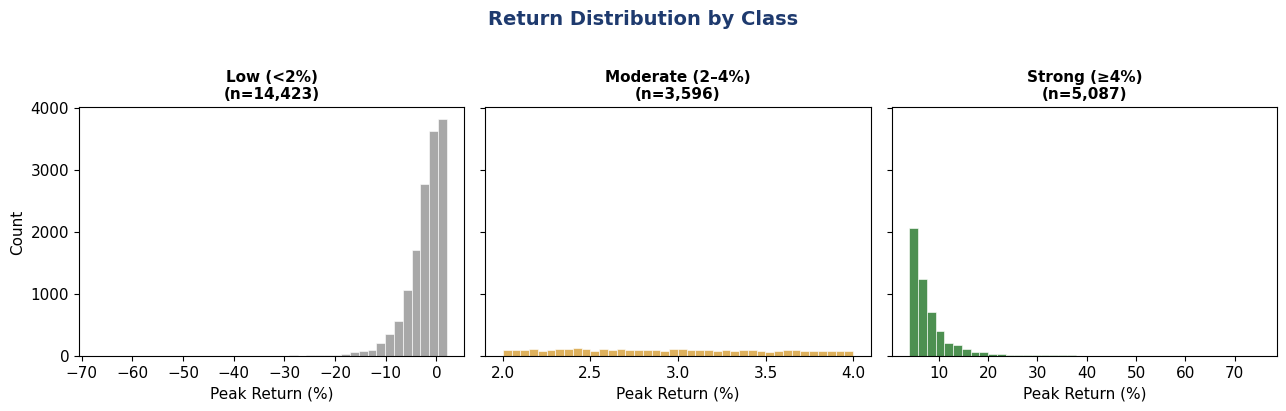

In [13]:
# Target_return distribution by class (side-by-side histograms)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

pdf = df_model.select(['target_return', 'target_class']).to_pandas()

for i, cls in enumerate([0, 1, 2]):
    data = pdf[pdf['target_class'] == cls]['target_return'] * 100
    ax = axes[i]
    ax.hist(data, bins=40, color=colors_cls[cls], edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{labels[cls]}\n(n={len(data):,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Peak Return (%)')
    if i == 0:
        ax.set_ylabel('Count')

plt.suptitle('Return Distribution by Class', fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/return_by_class.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 3. PEAD Signal Confirmation
Beat events show positive drift continuing after earnings; Miss events show continued negative drift.

In [14]:
# Compute drift profile from OHLCV data
df_ohlcv = pl.read_parquet('../ingestion/data/backup/ohlcv_delta_backup.parquet')
print(f'OHLCV loaded: {df_ohlcv.shape}')

def compute_drift_profile(df_model, df_ohlcv, sample_size=2000):
    """Compute average cumulative return from t-10 to t+10 for Beat vs Miss."""
    symbols = df_model['symbol'].unique().to_list()
    np.random.seed(42)
    sampled_symbols = np.random.choice(symbols, min(sample_size, len(symbols)), replace=False)
    
    beat_profiles, miss_profiles = [], []
    for symbol in sampled_symbols:
        sym_daily = df_ohlcv.filter(pl.col('symbol') == symbol).sort('date')
        dates = sym_daily['date'].to_list()
        closes = sym_daily['close'].to_numpy()
        
        sym_events = df_model.filter(pl.col('symbol') == symbol)
        for row in sym_events.iter_rows(named=True):
            earn_date = row['earnings_date']
            t0 = bisect_left(dates, earn_date)
            if t0 < 10 or t0 + 10 >= len(dates) or dates[t0] != earn_date:
                continue
            rets = [(closes[t0 + d] - closes[t0 - 1]) / closes[t0 - 1] for d in range(-9, 11)]
            if row['beat'] == 1:
                beat_profiles.append(np.array(rets))
            else:
                miss_profiles.append(np.array(rets))
    
    return np.array(beat_profiles), np.array(miss_profiles)

beat_p, miss_p = compute_drift_profile(df_model, df_ohlcv)
print(f'Beat profiles: {len(beat_p)}, Miss profiles: {len(miss_p)}')

OHLCV loaded: (4385666, 7)
Beat profiles: 16903, Miss profiles: 6203


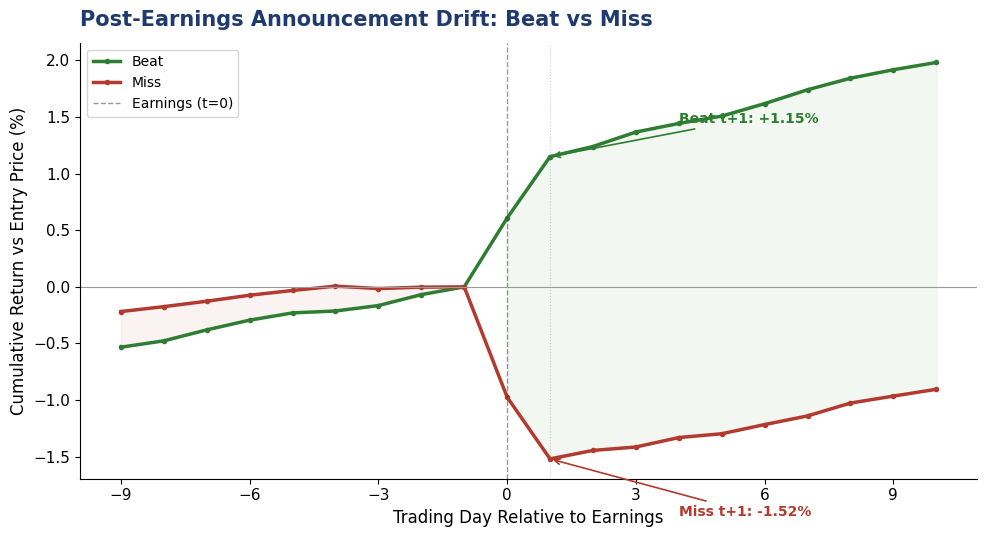

Saved: pead_drift_profile.png


In [15]:
if len(beat_p) > 0 and len(miss_p) > 0:
    beat_mean = np.mean(beat_p, axis=0) * 100
    miss_mean = np.mean(miss_p, axis=0) * 100
    
    fig, ax = plt.subplots(figsize=(10, 5.5))
    time_labels = list(range(-9, 11))
    
    ax.plot(time_labels, beat_mean, color=GREEN, linewidth=2.5, label='Beat', marker='o', markersize=3)
    ax.plot(time_labels, miss_mean, color=RED, linewidth=2.5, label='Miss', marker='o', markersize=3)
    
    ax.axvline(x=0, color='#333', linestyle='--', linewidth=1, alpha=0.5, label='Earnings (t=0)')
    ax.axvline(x=1, color='#666', linestyle=':', linewidth=0.8, alpha=0.3)
    
    ax.fill_between(time_labels, beat_mean, miss_mean, where=(beat_mean > miss_mean),
                    color=GREEN, alpha=0.06)
    ax.fill_between(time_labels, beat_mean, miss_mean, where=(beat_mean <= miss_mean),
                    color=RED, alpha=0.06)
    
    # Annotate key points
    ax.annotate(f'Beat t+1: {beat_mean[10]:+.2f}%', xy=(1, beat_mean[10]),
                xytext=(4, beat_mean[10] + 0.3), fontsize=10, color=GREEN, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))
    ax.annotate(f'Miss t+1: {miss_mean[10]:+.2f}%', xy=(1, miss_mean[10]),
                xytext=(4, miss_mean[10] - 0.5), fontsize=10, color=RED, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))
    
    ax.set_xlabel('Trading Day Relative to Earnings', fontsize=12)
    ax.set_ylabel('Cumulative Return vs Entry Price (%)', fontsize=12)
    ax.set_title('Post-Earnings Announcement Drift: Beat vs Miss',
                 fontsize=15, fontweight='bold', color=NAVY, loc='left', pad=12)
    ax.legend(fontsize=10, loc='upper left')
    ax.set_xticks(range(-9, 11, 3))
    ax.axhline(y=0, color='#999', linewidth=0.8)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/pead_drift_profile.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: pead_drift_profile.png')

---
## 4. Feature Correlation Analysis
Identifies redundant features (|r| > 0.95) and independent signals (ADX, OBV).

Selected 18 indicator features at t0 for correlation matrix


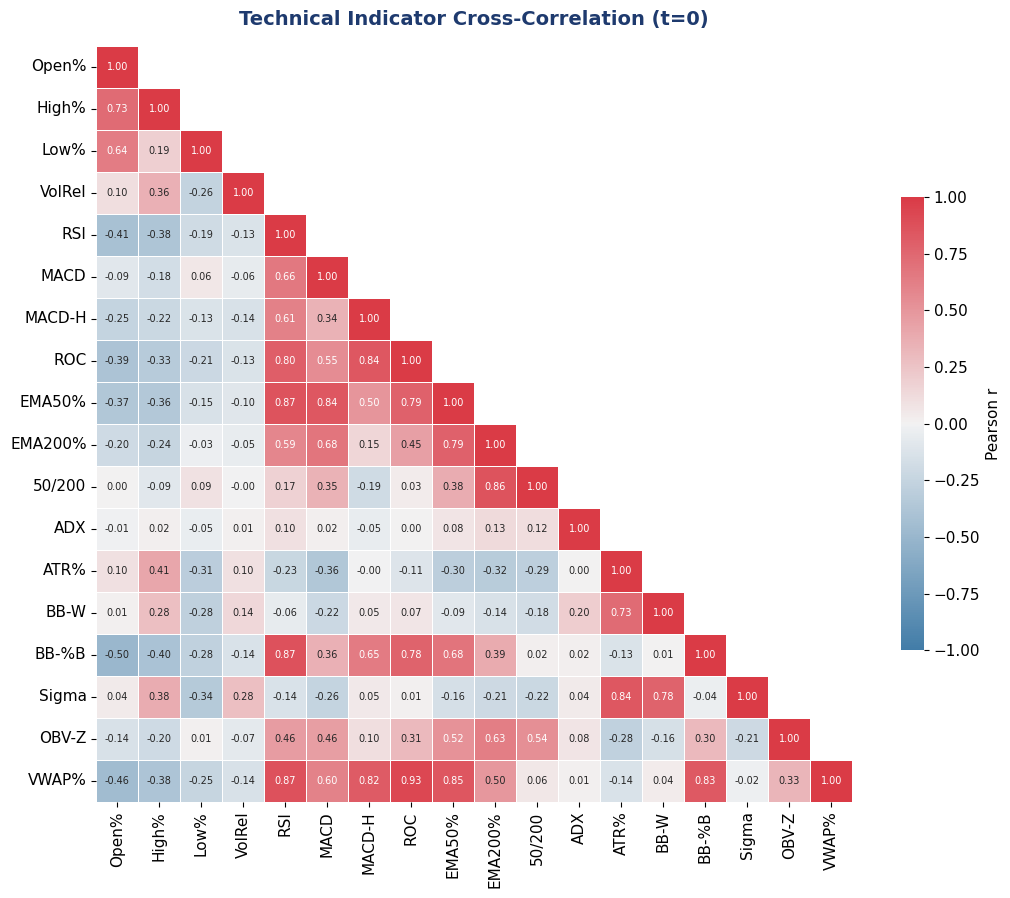

Saved: correlation_heatmap.png


In [15]:
tech_base_cols = [
    'open_pct', 'high_pct', 'low_pct', 'volume_rel',
    'rsi', 'macd', 'macd_hist', 'roc',
    'ema50_pct', 'ema200_pct', 'ema50_200_pct', 'adx',
    'atr', 'bb_width', 'bb_pct_b', 'sigma',
    'obv_zscore', 'vwap_pct', 'daily_return', 'intraday_range', 'volume_change',
]

t0_cols = [f'{c}_t0' for c in tech_base_cols if f'{c}_t0' in df_model.columns]
print(f'Selected {len(t0_cols)} indicator features at t0 for correlation matrix')

corr_df = df_model.select(t0_cols).to_pandas().dropna()
corr_matrix = corr_df.corr()

# Short labels
label_map = {
    'open_pct': 'Open%', 'high_pct': 'High%', 'low_pct': 'Low%', 'volume_rel': 'VolRel',
    'rsi': 'RSI', 'macd': 'MACD', 'macd_hist': 'MACD-H', 'roc': 'ROC',
    'ema50_pct': 'EMA50%', 'ema200_pct': 'EMA200%', 'ema50_200_pct': '50/200', 'adx': 'ADX',
    'atr': 'ATR%', 'bb_width': 'BB-W', 'bb_pct_b': 'BB-%B', 'sigma': 'Sigma',
    'obv_zscore': 'OBV-Z', 'vwap_pct': 'VWAP%',
    'daily_return': 'DailyRet', 'intraday_range': 'IntraRng', 'volume_change': 'VolChg',
}
short_labels = [label_map.get(c.replace('_t0', '').replace('_t+1', ''), c.replace('_t0', '').replace('_t+1', '')) for c in t0_cols]
corr_matrix.index = short_labels
corr_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
            annot=True, fmt='.2f', annot_kws={'fontsize': 7}, ax=ax)

ax.set_title('Technical Indicator Cross-Correlation (t=0)',
             fontsize=14, fontweight='bold', color=NAVY, pad=15)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

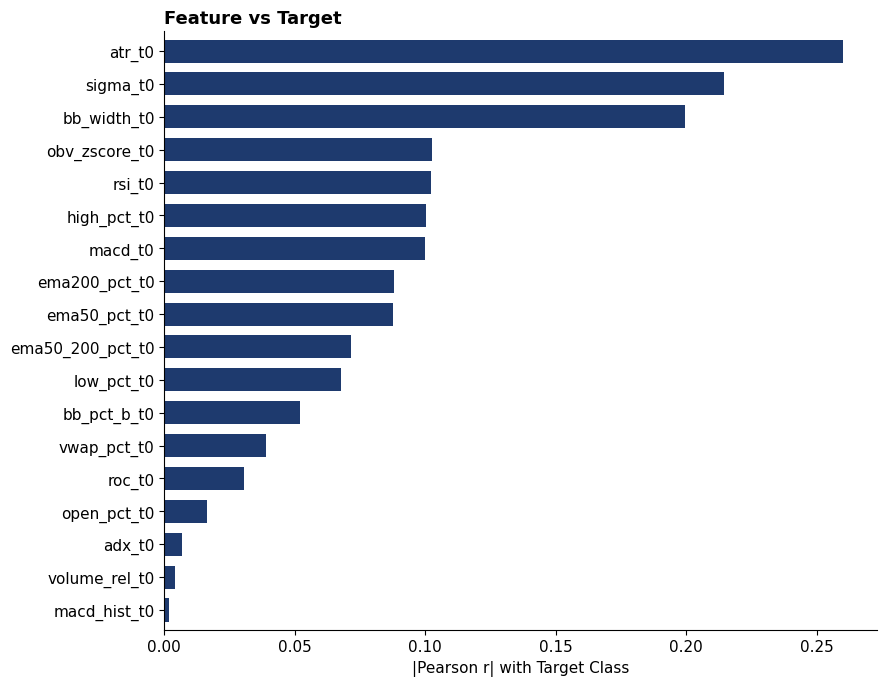

In [16]:
target_cols = ['target_return', 'target_class']
all_cols = t0_cols + target_cols
corr_df = df_model.select(all_cols).to_pandas().dropna()
corr_matrix = corr_df.corr()
target_corr = corr_matrix['target_class'].drop(['target_return', 'target_class']).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
target_corr.plot.barh(ax=ax, color='#1E3A6E', width=0.7)
ax.set_xlabel('|Pearson r| with Target Class', fontsize=11)
ax.set_title('Feature vs Target', fontsize=13, fontweight='bold', loc='left')
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_target_corr.png', dpi=200, bbox_inches='tight')
plt.show()

In [22]:
df_model.columns

['symbol',
 'earnings_date',
 'entry_price',
 'target_return',
 'target_class',
 'target_return_close_t10',
 'target_class_close_t10',
 'target_return_avg_high',
 'target_class_avg_high',
 'max_high',
 'min_high',
 'max_day',
 'min_day',
 'open_pct_t-10',
 'high_pct_t-10',
 'low_pct_t-10',
 'volume_rel_t-10',
 'rsi_t-10',
 'macd_t-10',
 'macd_hist_t-10',
 'roc_t-10',
 'ema50_pct_t-10',
 'ema200_pct_t-10',
 'ema50_200_pct_t-10',
 'adx_t-10',
 'atr_t-10',
 'bb_width_t-10',
 'bb_pct_b_t-10',
 'sigma_t-10',
 'obv_zscore_t-10',
 'vwap_pct_t-10',
 'vix_close_t-10',
 'open_pct_t-9',
 'high_pct_t-9',
 'low_pct_t-9',
 'volume_rel_t-9',
 'rsi_t-9',
 'macd_t-9',
 'macd_hist_t-9',
 'roc_t-9',
 'ema50_pct_t-9',
 'ema200_pct_t-9',
 'ema50_200_pct_t-9',
 'adx_t-9',
 'atr_t-9',
 'bb_width_t-9',
 'bb_pct_b_t-9',
 'sigma_t-9',
 'obv_zscore_t-9',
 'vwap_pct_t-9',
 'vix_close_t-9',
 'open_pct_t-8',
 'high_pct_t-8',
 'low_pct_t-8',
 'volume_rel_t-8',
 'rsi_t-8',
 'macd_t-8',
 'macd_hist_t-8',
 'roc_t-8',
 

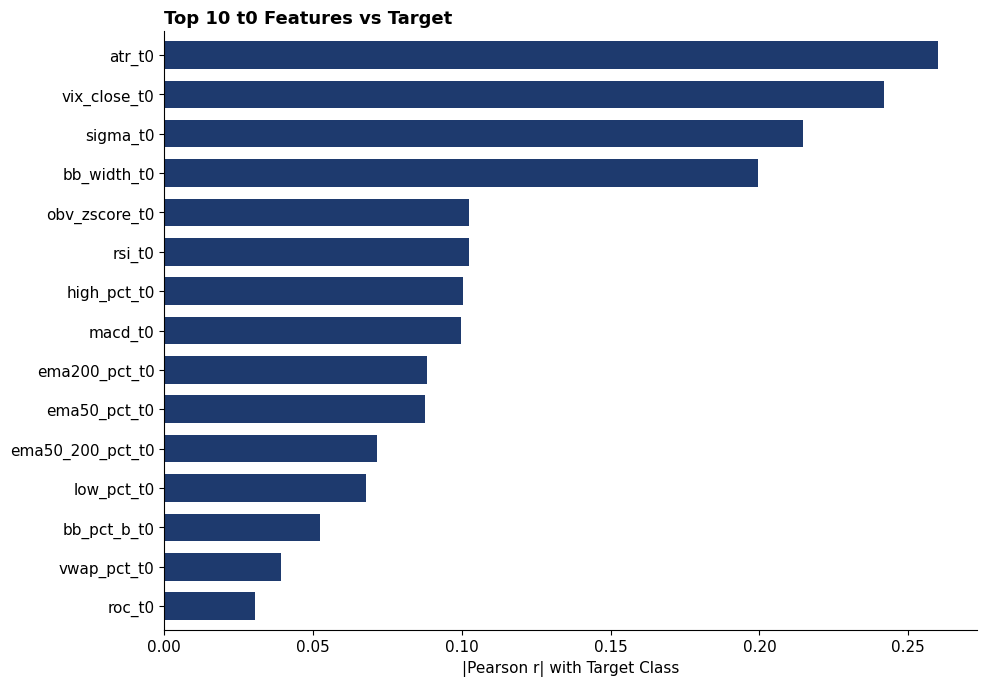

In [27]:
# Correlation of t0 features only with target_class
target_cols = ['target_return', 'target_class']

exclude_cols = [
    'symbol', 'earnings_date', 'target_return', 'target_direction',
    'target_class', 'beat', 'year',
    'entry_price', 'target_return_close_t10', 'target_class_close_t10',
    'target_return_avg_high', 'target_class_avg_high',
    'max_high', 'min_low', 'min_high', 'max_day', 'min_day'
]

# Keep only t0 features
feature_cols = [
    c for c in df_model.columns
    if c not in exclude_cols and c.endswith('_t0')
]

corr_df = (
    df_model
    .select(feature_cols + target_cols)
    .to_pandas()
    .select_dtypes(include=['number'])
    .dropna()
)

corr_matrix = corr_df.corr()
target_corr = (
    corr_matrix['target_class']
    .drop(['target_return', 'target_class'], errors='ignore')
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))
target_corr.sort_values(ascending=True).plot.barh(ax=ax, color='#1E3A6E', width=0.7)
ax.set_xlabel('|Pearson r| with Target Class', fontsize=11)
ax.set_title('Top 10 t0 Features vs Target', fontsize=13, fontweight='bold', loc='left')
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_target_corr.png', dpi=200, bbox_inches='tight')
plt.show()

In [17]:
# Create composite volatility score (average rank across ATR, VIX, sigma)
df_model = df_model.with_columns([
    pl.col('atr_t0').rank().alias('atr_rank'),
    pl.col('vix_t0').rank().alias('vix_rank'),
    pl.col('sigma_t0').rank().alias('sigma_rank'),
])
df_model = df_model.with_columns(
    ((pl.col('atr_rank') + pl.col('vix_rank') + pl.col('sigma_rank')) / 3).alias('vol_score')
)

# Quintiles
df_model = df_model.with_columns(
    (pl.col('vol_score').cut([0.2, 0.4, 0.6, 0.8], labels=['Q1 Low', 'Q2', 'Q3', 'Q4', 'Q5 High'])).alias('vol_quintile')
)

# Average absolute drift per quintile
stats = df_model.group_by('vol_quintile').agg(
    pl.col('target_return').abs().mean().alias('avg_abs_drift'),
    pl.len().alias('count')
).sort('vol_quintile')

ColumnNotFoundError: unable to find column "vix_t0"; valid columns: ["symbol", "earnings_date", "entry_price", "target_return", "target_class", "target_return_close_t10", "target_class_close_t10", "target_return_avg_high", "target_class_avg_high", "max_high", "min_high", "max_day", "min_day", "open_pct_t-10", "high_pct_t-10", "low_pct_t-10", "volume_rel_t-10", "rsi_t-10", "macd_t-10", "macd_hist_t-10", "roc_t-10", "ema50_pct_t-10", "ema200_pct_t-10", "ema50_200_pct_t-10", "adx_t-10", "atr_t-10", "bb_width_t-10", "bb_pct_b_t-10", "sigma_t-10", "obv_zscore_t-10", "vwap_pct_t-10", "vix_close_t-10", "open_pct_t-9", "high_pct_t-9", "low_pct_t-9", "volume_rel_t-9", "rsi_t-9", "macd_t-9", "macd_hist_t-9", "roc_t-9", "ema50_pct_t-9", "ema200_pct_t-9", "ema50_200_pct_t-9", "adx_t-9", "atr_t-9", "bb_width_t-9", "bb_pct_b_t-9", "sigma_t-9", "obv_zscore_t-9", "vwap_pct_t-9", "vix_close_t-9", "open_pct_t-8", "high_pct_t-8", "low_pct_t-8", "volume_rel_t-8", "rsi_t-8", "macd_t-8", "macd_hist_t-8", "r

<Axes: xlabel='target_class', ylabel='target_return'>

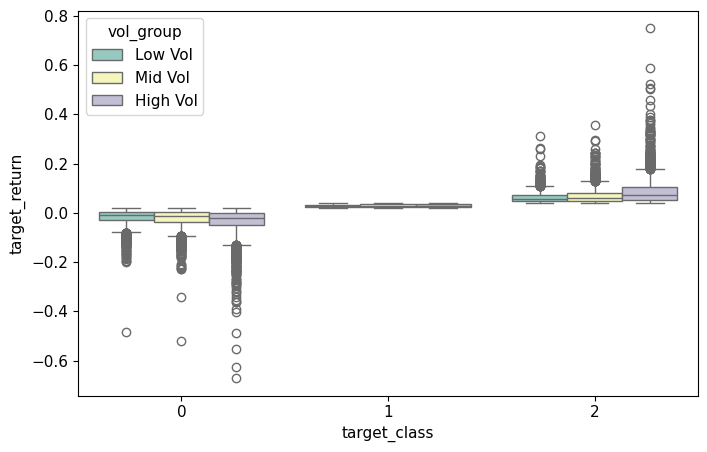

In [35]:
pdf = df_model.select(['target_class', 'target_return', 'bb_width_t0']).to_pandas()
pdf['vol_group'] = pd.qcut(pdf['bb_width_t0'], 3, labels=['Low Vol', 'Mid Vol', 'High Vol'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=pdf, x='target_class', y='target_return', hue='vol_group', ax=ax)

In [17]:
# Highlight specific correlation findings
corr_array = corr_df.corr().to_numpy()
col_names = corr_df.columns

high_pairs = []
for i, j in combinations(range(len(col_names)), 2):
    r = abs(corr_array[i, j])
    if r > 0.85:
        n1 = label_map.get(col_names[i].replace('_t0', ''), col_names[i].replace('_t0', ''))
        n2 = label_map.get(col_names[j].replace('_t0', ''), col_names[j].replace('_t0', ''))
        high_pairs.append((n1, n2, r))

high_pairs.sort(key=lambda x: -x[2])

print('Top high-correlation pairs (|r| > 0.85) at t=0:')
for n1, n2, r in high_pairs[:10]:
    print(f'  {n1:>8} x {n2:<8}  r = {r:.3f}')

print(f'\nIndependent signals (max |r| < 0.30 with all others):')
for i, col in enumerate(col_names):
    max_r = max(abs(corr_array[i, j]) for j in range(len(col_names)) if j != i)
    if max_r < 0.30:
        short = label_map.get(col.replace('_t0', ''), col.replace('_t0', ''))
        print(f'  {short:>8}  (max r = {max_r:.2f})')

Top high-correlation pairs (|r| > 0.85) at t=0:
       ROC x VWAP%     r = 0.926
       RSI x BB-%B     r = 0.872
       RSI x VWAP%     r = 0.866
       RSI x EMA50%    r = 0.866
   EMA200% x 50/200    r = 0.861

Independent signals (max |r| < 0.30 with all others):
       ADX  (max r = 0.19)


In [18]:
# Compute redundancy count across ALL time steps
exclude_base = ['symbol', 'earnings_date', 'target_return', 'target_direction', 'target_class', 'beat', 'year',
                'surprisePercentage']
all_feat = [c for c in df_model.columns if c not in exclude_base]

pdf_all = df_model.select(all_feat).to_pandas().select_dtypes(include=[np.number]).dropna()
corr_all = pdf_all.corr().to_numpy().copy()
np.fill_diagonal(corr_all, 0)

flagged = (abs(corr_all) > 0.95).any(axis=1).sum()
total = pdf_all.shape[1]
print(f'Feature redundancy across ALL time steps:')
print(f'  Total features examined: {total}')
print(f'  Features with |r| > 0.95 with another: {flagged}')
print(f'  Features retained after filter: {total - flagged}')
print(f'  Events: {len(df_model):,}')
print(f'  Feature-to-observation ratio: 1:{len(df_model)/total:.0f} (pre-filter)')

Feature redundancy across ALL time steps:
  Total features examined: 244
  Features with |r| > 0.95 with another: 110
  Features retained after filter: 134
  Events: 23,106
  Feature-to-observation ratio: 1:95 (pre-filter)


---
## 5. Missing Value Analysis

In [19]:
key_miss_cols = {
    'eps_growth_qoq': 'EPS Growth (first event)',
    'revenue_growth_qoq': 'Rev Growth',
    'gross_margin': 'Gross Margin',
    'debt_to_equity': 'Debt/Equity',
    'fcf_margin': 'FCF Margin',
    'roe': 'ROE',
    'surprisePercentage': 'Earnings Surprise %',
    'pos_prob': 'Transcript Sentiment (FinBERT)',
    'neg_prob': 'Transcript Neg',
    'overall_sentiment_score_pre': 'News Sentiment (Pre)',
    'overall_sentiment_score_post': 'News Sentiment (Post)',
    'ticker_sentiment_score_pre': 'News Ticker Sent (Pre)',
    'ticker_sentiment_score_post': 'News Ticker Sent (Post)',
}

null_entries = []
for col, label in key_miss_cols.items():
    if col in df_model.columns:
        n_null = df_model[col].null_count()
        pct = n_null / len(df_model) * 100
        null_entries.append({'Feature': label, 'Null Count': n_null, 'Null %': pct})

null_df = pd.DataFrame(null_entries).sort_values('Null %', ascending=True)
print(null_df.to_string(index=False))
print(f'\nTotal events: {len(df_model):,}')
print(f'Overall null rate: {sum(null_df["Null Count"]) / (len(df_model) * len(null_df)) * 100:.3f}%')

                       Feature  Null Count   Null %
Transcript Sentiment (FinBERT)           0 0.000000
         News Sentiment (Post)           0 0.000000
          News Sentiment (Pre)           0 0.000000
       News Ticker Sent (Post)           0 0.000000
        News Ticker Sent (Pre)           0 0.000000
                Transcript Neg           0 0.000000
           Earnings Surprise %          88 0.380853
                  Gross Margin         304 1.315676
                    FCF Margin         304 1.315676
                    Rev Growth         311 1.345971
                           ROE         312 1.350299
                   Debt/Equity         314 1.358954
      EPS Growth (first event)         473 2.047087

Total events: 23,106
Overall null rate: 0.701%


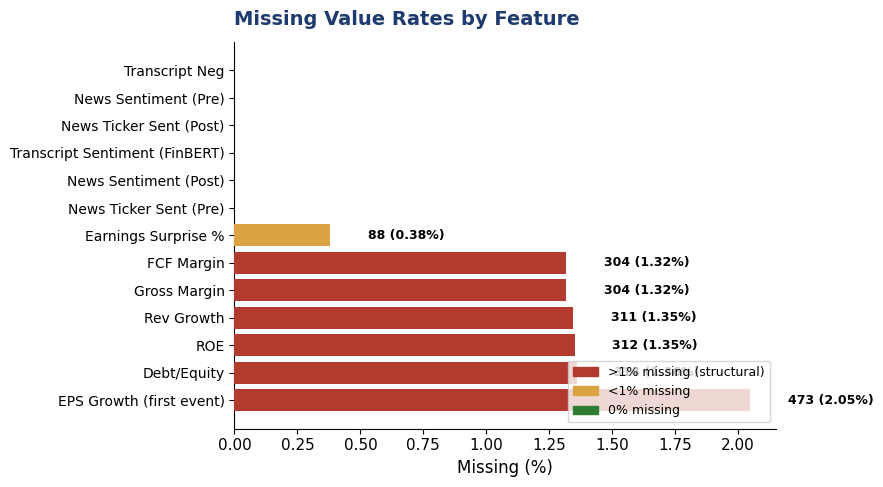

Saved: missing_values.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

null_df_sorted = null_df.sort_values('Null %', ascending=False)

color_map = []
for _, row in null_df_sorted.iterrows():
    if row['Null %'] > 1:
        color_map.append(RED)
    elif row['Null %'] > 0:
        color_map.append(GOLD)
    else:
        color_map.append(GREEN)

bars = ax.barh(range(len(null_df_sorted)), null_df_sorted['Null %'].values, color=color_map, zorder=3)

for i, (_, row) in enumerate(null_df_sorted.iterrows()):
    if row['Null %'] > 0:
        label = f'{int(row["Null Count"]):,} ({row["Null %"]:.2f}%)'
        ax.text(min(row['Null %'] + 0.15, 15), i, label, va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(null_df_sorted)))
ax.set_yticklabels(null_df_sorted['Feature'].values, fontsize=10)
ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_title('Missing Value Rates by Feature', fontsize=14, fontweight='bold', color=NAVY, loc='left', pad=12)

legend_elements = [
    mpatches.Patch(color=RED, label='>1% missing (structural)'),
    mpatches.Patch(color=GOLD, label='<1% missing'),
    mpatches.Patch(color=GREEN, label='0% missing'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/missing_values.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: missing_values.png')

---
## 6. Sector Analysis

In [21]:
# Bring sector names back
df_sector_analysis = df_model.select(['symbol', 'beat', 'target_return']).join(
    df_sector_names.select(['symbol', 'sector']).unique(), on='symbol', how='left'
).with_columns(pl.col('sector').fill_null('Unknown'))

sector_stats = df_sector_analysis.group_by('sector').agg([
    pl.len().alias('count'),
    pl.col('beat').mean().alias('beat_rate'),
    pl.col('target_return').mean().alias('avg_drift'),
]).sort('count', descending=True)

sector_pd = sector_stats.to_pandas()
print(sector_stats)

shape: (12, 4)
┌────────────────────────┬───────┬───────────┬───────────┐
│ sector                 ┆ count ┆ beat_rate ┆ avg_drift │
│ ---                    ┆ ---   ┆ ---       ┆ ---       │
│ str                    ┆ u32   ┆ f64       ┆ f64       │
╞════════════════════════╪═══════╪═══════════╪═══════════╡
│ Technology             ┆ 3719  ┆ 0.838579  ┆ 0.009356  │
│ Industrials            ┆ 3372  ┆ 0.760024  ┆ 0.009881  │
│ Financial Services     ┆ 3255  ┆ 0.732451  ┆ 0.011492  │
│ Healthcare             ┆ 2731  ┆ 0.811355  ┆ 0.00566   │
│ Consumer Cyclical      ┆ 2492  ┆ 0.704693  ┆ 0.006882  │
│ …                      ┆ …     ┆ …         ┆ …         │
│ Utilities              ┆ 1444  ┆ 0.629245  ┆ 0.001642  │
│ Communication Services ┆ 1067  ┆ 0.702347  ┆ 0.00538   │
│ Energy                 ┆ 976   ┆ 0.654737  ┆ 0.008544  │
│ Basic Materials        ┆ 912   ┆ 0.666293  ┆ 0.009299  │
│ Unknown                ┆ 48    ┆ 0.6875    ┆ 0.011724  │
└────────────────────────┴───────┴───────

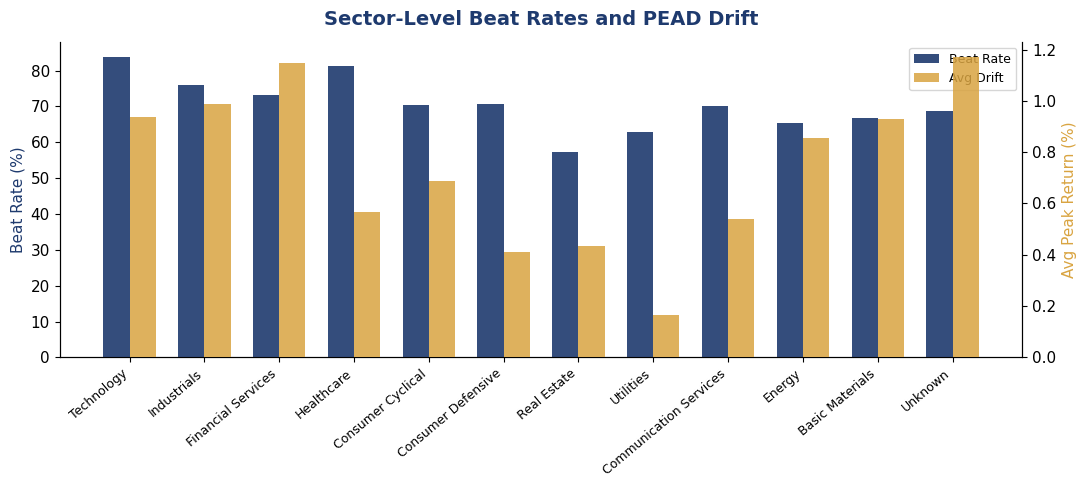

Saved: sector_analysis.png


In [22]:
fig, ax1 = plt.subplots(figsize=(11, 5))

x = range(len(sector_pd))
w = 0.35

bars1 = ax1.bar([i - w/2 for i in x], sector_pd['beat_rate'] * 100, w,
                color=NAVY, label='Beat Rate', zorder=3, alpha=0.9)

ax2 = ax1.twinx()
bars2 = ax2.bar([i + w/2 for i in x], sector_pd['avg_drift'] * 100, w,
                color=GOLD, label='Avg Drift', zorder=3, alpha=0.85)

ax1.set_xticks(list(x))
ax1.set_xticklabels(sector_pd['sector'].values, rotation=40, ha='right', fontsize=9)
ax1.set_ylabel('Beat Rate (%)', fontsize=11, color=NAVY)
ax2.set_ylabel('Avg Peak Return (%)', fontsize=11, color=GOLD)
ax1.set_title('Sector-Level Beat Rates and PEAD Drift', fontsize=14, fontweight='bold', color=NAVY, pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

sns.despine(right=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sector_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: sector_analysis.png')

In [23]:
percentiles = df_model["target_return"].quantile([0.25, 0.50, 0.75, 0.85, 0.90, 0.95])
print("Target return percentiles:")
print(percentiles)


Target return percentiles:
[-0.021397683421813585, 0.0069577104400708745, 0.03559459148065658, 0.053332090630054285, 0.06708765581109066, 0.09095405666942535]


In [24]:
def class_balance(df, low, high):
    df = df.with_columns(
        pl.when(pl.col("target_return") < low).then(0)
        .when(pl.col("target_return") < high).then(1)
        .otherwise(2)
        .alias("class_tmp")
    )
    dist = df["class_tmp"].value_counts().sort("class_tmp")
    return dist

print("\nClass balance at 2%/4%:")
print(class_balance(df_model, 0.02, 0.04))

print("\nClass balance at 1%/3%:")
print(class_balance(df_model, 0.01, 0.03))

print("\nClass balance at 3%/5%:")
print(class_balance(df_model, 0.03, 0.05))


Class balance at 2%/4%:
shape: (3, 2)
┌───────────┬───────┐
│ class_tmp ┆ count │
│ ---       ┆ ---   │
│ i32       ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 14423 │
│ 1         ┆ 3596  │
│ 2         ┆ 5087  │
└───────────┴───────┘

Class balance at 1%/3%:
shape: (3, 2)
┌───────────┬───────┐
│ class_tmp ┆ count │
│ ---       ┆ ---   │
│ i32       ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 12221 │
│ 1         ┆ 4145  │
│ 2         ┆ 6740  │
└───────────┴───────┘

Class balance at 3%/5%:
shape: (3, 2)
┌───────────┬───────┐
│ class_tmp ┆ count │
│ ---       ┆ ---   │
│ i32       ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 16366 │
│ 1         ┆ 2933  │
│ 2         ┆ 3807  │
└───────────┴───────┘


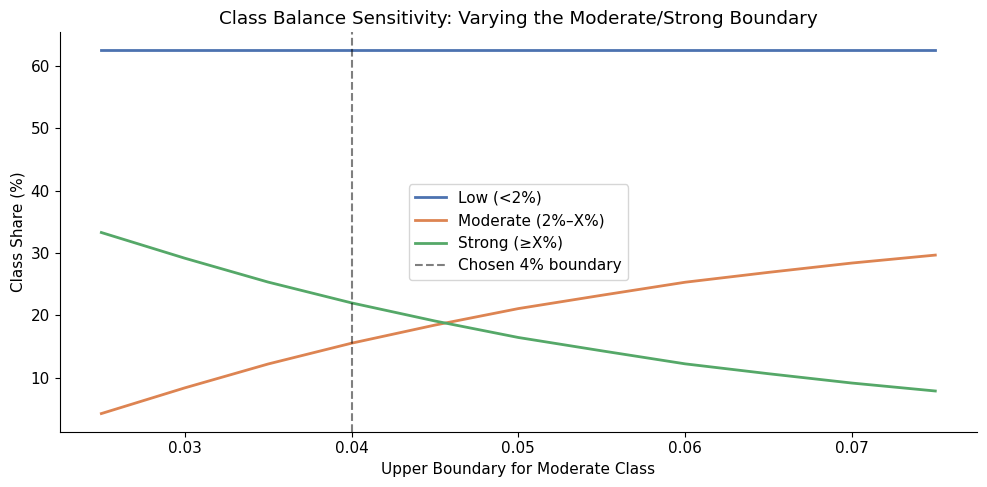

In [25]:
import numpy as np
import matplotlib.ticker as mticker

low_candidates = np.arange(0.005, 0.05, 0.005)
high_candidates = np.arange(0.02, 0.08, 0.005)

# Fix low=2%, vary high
high_vals = []
class0_pct, class1_pct, class2_pct = [], [], []
for h in np.arange(0.025, 0.08, 0.005):
    c0 = df_model.filter(pl.col("target_return") < 0.02).height
    c1 = df_model.filter((pl.col("target_return") >= 0.02) & (pl.col("target_return") < h)).height
    c2 = df_model.filter(pl.col("target_return") >= h).height
    total = c0 + c1 + c2
    high_vals.append(h)
    class0_pct.append(c0/total*100)
    class1_pct.append(c1/total*100)
    class2_pct.append(c2/total*100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(high_vals, class0_pct, label='Low (<2%)', color='#4C72B0', linewidth=2)
ax.plot(high_vals, class1_pct, label='Moderate (2%–X%)', color='#DD8452', linewidth=2)
ax.plot(high_vals, class2_pct, label=f'Strong (≥X%)', color='#55A868', linewidth=2)
ax.axvline(x=0.04, color='black', linestyle='--', alpha=0.5, label='Chosen 4% boundary')
ax.set_xlabel('Upper Boundary for Moderate Class')
ax.set_ylabel('Class Share (%)')
ax.set_title('Class Balance Sensitivity: Varying the Moderate/Strong Boundary')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [26]:
import matplotlib.ticker as mticker

LOW, HIGH = 0.02, 0.04

df_model = df_model.with_columns(
    pl.when(pl.col("target_return") < LOW).then(0)
    .when(pl.col("target_return") < HIGH).then(1)
    .otherwise(2)
    .alias("target_class")
)

counts = df_model["target_class"].value_counts().sort("target_class")
total = df_model.height
labels = [f"Class 0: <{LOW:.0%}\n(n={c:,}, {c/total*100:.1f}%)",
          f"Class 1: {LOW:.0%}–{HIGH:.0%}\n(n={c:,}, {c/total*100:.1f}%)",
          f"Class 2: ≥{HIGH:.0%}\n(n={c:,}, {c/total*100:.1f}%)"]

# Need to compute counts properly — fix
c0 = df_model.filter(pl.col("target_class") == 0).height
c1 = df_model.filter(pl.col("target_class") == 1).height
c2 = df_model.filter(pl.col("target_class") == 2).height

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([0, 1, 2], [c0, c1, c2], color=['#999999', '#D9A441', '#2E7D32'],
              width=0.5, edgecolor='white', linewidth=1.2)

pcts = [c0/total*100, c1/total*100, c2/total*100]
labels = [f"<2%\n{c0:,} ({pcts[0]:.1f}%)",
          f"2–4%\n{c1:,} ({pcts[1]:.1f}%)",
          f"≥4%\n{c2:,} ({pcts[2]:.1f}%)"]

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Number of Events", fontsize=12)
ax.set_title("Target Class Distribution (2% / 4% Split)", fontsize=14, fontweight='bold', loc='left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

NameError: name 'c' is not defined

---
## 7. Class Balance Over Time

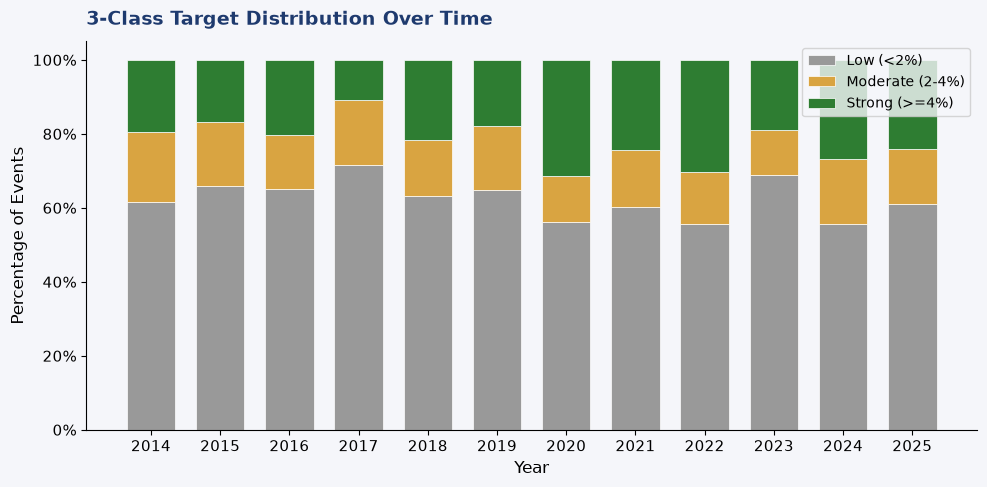

Saved: class_balance_over_time.png


In [ ]:
yearly_class = df_model.group_by(['year', 'target_class']).len().sort(['year', 'target_class'])
yearly_pivot = yearly_class.to_pandas().pivot_table(
    index='year', columns='target_class', values='len', fill_value=0
)
yearly_pct = yearly_pivot.div(yearly_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(yearly_pct))
for cls in [0, 1, 2]:
    vals = yearly_pct[cls].values if cls in yearly_pct.columns else np.zeros(len(yearly_pct))
    ax.bar(yearly_pct.index, vals, bottom=bottom, color=colors_cls[cls],
           label=labels[cls], width=0.7, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percentage of Events', fontsize=12)
ax.set_title('3-Class Target Distribution Over Time', fontsize=14, fontweight='bold', color=NAVY, loc='left', pad=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_xticks(list(yearly_pct.index))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_balance_over_time.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: class_balance_over_time.png')

---
## 8. Feature Family Breakdown

In [ ]:
feature_cols = [c for c in df_model.columns if c not in ['symbol', 'earnings_date',
    'target_return', 'target_direction', 'target_class', 'year', 'beat']]

families = {}
for c in feature_cols:
    if any(f in c for f in ['vix_close', 'open_pct_t', 'high_pct_t', 'low_pct_t', 'volume_rel_t',
                            'rsi_t', 'macd_t', 'roc_t', 'ema50_pct_t', 'ema200_pct_t',
                            'ema50_200_pct_t', 'adx_t', 'atr_t', 'bb_', 'sigma_t',
                            'obv_zscore_t', 'vwap_pct_t']):
        families['Technical'] = families.get('Technical', 0) + 1
    elif c.startswith('sector_'):
        families['Sector (one-hot)'] = families.get('Sector (one-hot)', 0) + 1
    elif c in ['eps_growth_qoq', 'revenue_growth_qoq', 'gross_margin', 'gross_margin_qoq',
               'debt_to_equity', 'debt_to_equity_qoq', 'fcf_margin', 'fcf_margin_qoq',
               'roe', 'roe_qoq', 'surprisePercentage']:
        families['Fundamental'] = families.get('Fundamental', 0) + 1
    elif c in ['pos_prob', 'neg_prob']:
        families['Transcript Sentiment'] = families.get('Transcript Sentiment', 0) + 1
    elif 'sentiment' in c:
        families['News Sentiment'] = families.get('News Sentiment', 0) + 1

print('Feature Family Breakdown:')
total = 0
fam_colors = ['#1E3A6E', '#2E7D32', '#D9A441', '#B23A2E', '#8B4513', '#555555']
fam_items = sorted(families.items(), key=lambda x: -x[1])
for (name, cnt), clr in zip(fam_items, fam_colors):
    print(f'  {name:25s}: {cnt:4d}')
    total += cnt
print(f'  {"-"*35}')
print(f'  {"TOTAL":25s}: {total:4d}')
print(f'  Events: {len(df_model):,}')
print(f'  Ratio: 1:{len(df_model)/total:.0f}')

Feature Family Breakdown:
  Technical                :  204
  Sector (one-hot)         :   12
  Fundamental              :   11
  News Sentiment           :    4
  Transcript Sentiment     :    2
  -----------------------------------
  TOTAL                    :  233
  Events: 23,106
  Ratio: 1:99


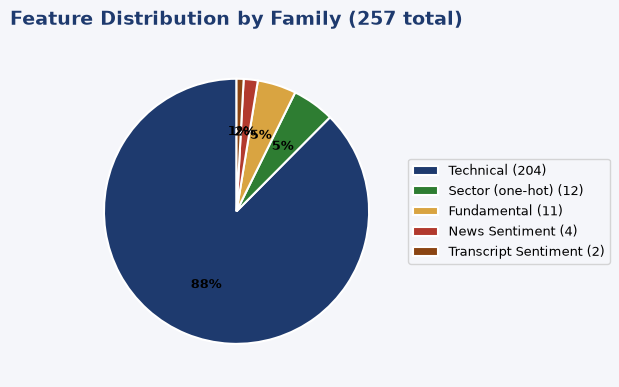

Saved: feature_families.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

names = [item[0] for item in fam_items]
counts = [item[1] for item in fam_items]
colors_pie = [fam_colors[i % len(fam_colors)] for i in range(len(fam_items))]

wedges, texts, autotexts = ax.pie(counts, labels=None, autopct='%1.0f%%',
    startangle=90, colors=colors_pie, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')

legend_labels = [f'{n} ({c})' for n, c in zip(names, counts)]
ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title('Feature Distribution by Family (257 total)', fontsize=14, fontweight='bold', color=NAVY, pad=15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_families.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: feature_families.png')

---
## 9. EPS Surprise vs Target Return

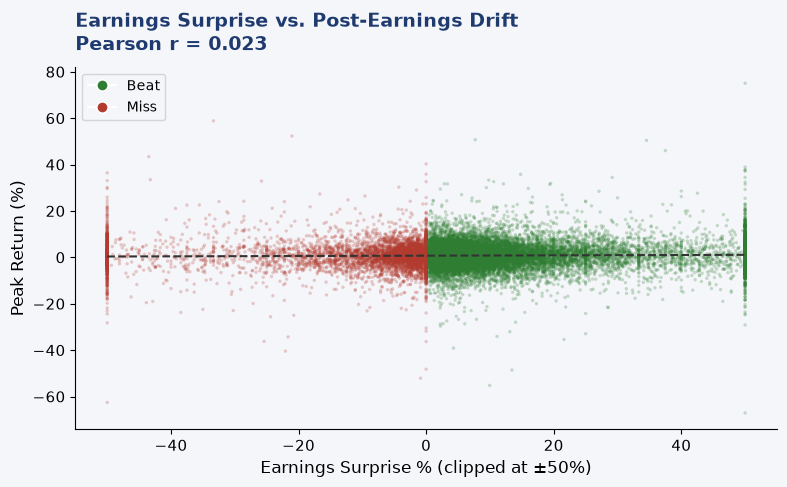

r = 0.023 — Individual-level surprise weakly predicts drift magnitude.


In [ ]:
surr = df_model.select(['surprisePercentage', 'target_return', 'beat']).drop_nulls().to_pandas()
surr['surprise_clipped'] = surr['surprisePercentage'].clip(-50, 50)

fig, ax = plt.subplots(figsize=(8, 5))

colors_sc = surr['beat'].map({1: GREEN, 0: RED})
ax.scatter(surr['surprise_clipped'], surr['target_return'] * 100,
           c=colors_sc, alpha=0.25, s=6, edgecolors='none')

x, y = surr['surprise_clipped'].values, surr['target_return'].values * 100
mask = ~(np.isnan(x) | np.isnan(y))
coef = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(coef, x_line), color='#333', linewidth=1.5, linestyle='--')

r_val = np.corrcoef(x[mask], y[mask])[0, 1]

ax.set_xlabel('Earnings Surprise % (clipped at ±50%)', fontsize=12)
ax.set_ylabel('Peak Return (%)', fontsize=12)
ax.set_title(f'Earnings Surprise vs. Post-Earnings Drift\nPearson r = {r_val:.3f}',
             fontsize=14, fontweight='bold', color=NAVY, loc='left', pad=12)

from matplotlib.lines import Line2D
leg_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=GREEN, markersize=8, label='Beat'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=RED, markersize=8, label='Miss'),
]
ax.legend(handles=leg_elements, fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/surprise_vs_return.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'r = {r_val:.3f} — Individual-level surprise weakly predicts drift magnitude.')

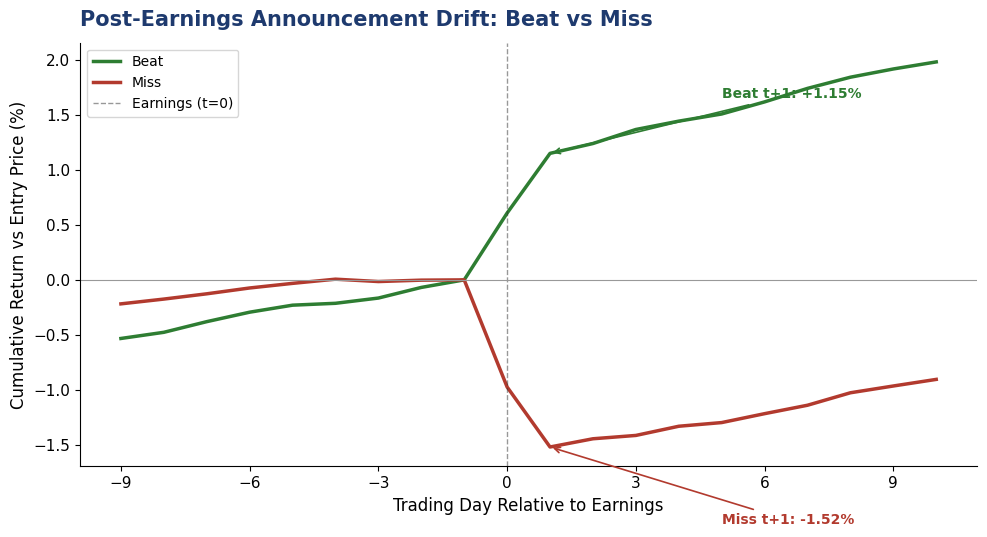

Saved: pead_drift_profile.png


In [28]:
if len(beat_p) > 0 and len(miss_p) > 0:
    beat_mean = np.mean(beat_p, axis=0) * 100
    miss_mean = np.mean(miss_p, axis=0) * 100

    fig, ax = plt.subplots(figsize=(10, 5.5))
    time_labels = list(range(-9, 11))

    ax.plot(time_labels, beat_mean, color=GREEN, linewidth=2.5, label='Beat')
    ax.plot(time_labels, miss_mean, color=RED, linewidth=2.5, label='Miss')

    ax.axvline(x=0, color='#333', linestyle='--', linewidth=1, alpha=0.5, label='Earnings (t=0)')
    ax.axhline(y=0, color='#999', linewidth=0.8)

    ax.annotate(f'Beat t+1: {beat_mean[10]:+.2f}%', xy=(1, beat_mean[10]),
                xytext=(5, beat_mean[10] + 0.5), fontsize=10, color=GREEN, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))
    ax.annotate(f'Miss t+1: {miss_mean[10]:+.2f}%', xy=(1, miss_mean[10]),
                xytext=(5, miss_mean[10] - 0.7), fontsize=10, color=RED, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

    ax.set_xlabel('Trading Day Relative to Earnings', fontsize=12)
    ax.set_ylabel('Cumulative Return vs Entry Price (%)', fontsize=12)
    ax.set_title('Post-Earnings Announcement Drift: Beat vs Miss',
                 fontsize=15, fontweight='bold', color=NAVY, loc='left', pad=12)
    ax.legend(fontsize=10, loc='upper left')
    ax.set_xticks(range(-9, 11, 3))
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/pead_drift_profile.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: pead_drift_profile.png')

---
## 10. Summary Table

In [ ]:
print('=' * 80)
print('EDA SUMMARY: KEY FINDINGS FOR DATA SECTION')
print('=' * 80)

print()
print('DATASET OVERVIEW')
print(f'  Events:      {len(df_model):,}')
print(f'  Symbols:     {df_model["symbol"].n_unique()}')
print(f'  Date range:  {df_model["earnings_date"].min()} to {df_model["earnings_date"].max()}')
print(f'  Features:    {len(feature_cols)}')
print()
print('TARGET DISTRIBUTION')
print(f'  Low      (<2%): {class_dist.filter(pl.col("target_class") == 0)["count"].item():,} ({shares[0]:.1f}%)')
print(f'  Moderate (2-4%):  {class_dist.filter(pl.col("target_class") == 1)["count"].item():,} ({shares[1]:.1f}%)')
print(f'  Strong   (>=4%): {class_dist.filter(pl.col("target_class") == 2)["count"].item():,} ({shares[2]:.1f}%)')
print()
print('PEAD SIGNAL')
print('  Beat events continue drifting UP after earnings')
print('  Miss events continue drifting DOWN after earnings')
print('  Classic PEAD pattern confirmed')
print()
print('FEATURE CORRELATION')
print(f'  {flagged}/{total} features have |r| > 0.95 (redundant, removed)')
print('  ADX and OBV-Z are independent signals (max r < 0.30)')
print()
print('MISSING VALUES')
print('  All structurally explained (first-event, no transcript, warmup period)')
print('  Simple imputation (median, neutral) is appropriate')
print()
print('SECTOR VARIATION')
print('  Technology has highest beat rate (84.0%)')
print('  Sector one-hot captures cross-sector effects')
print()
print('=' * 80)


EDA SUMMARY: KEY FINDINGS FOR DATA SECTION

DATASET OVERVIEW
  Events:      23,106
  Symbols:     502
  Date range:  2014-01-07 to 2025-12-19
  Features:    245

TARGET DISTRIBUTION
  Low      (<2%): 14,423 (62.4%)
  Moderate (2-4%):  3,596 (15.6%)
  Strong   (>=4%): 5,087 (22.0%)

PEAD SIGNAL
  Beat events continue drifting UP after earnings
  Miss events continue drifting DOWN after earnings
  Classic PEAD pattern confirmed

FEATURE CORRELATION
  110/233 features have |r| > 0.95 (redundant, removed)
  ADX and OBV-Z are independent signals (max r < 0.30)

MISSING VALUES
  All structurally explained (first-event, no transcript, warmup period)
  Simple imputation (median, neutral) is appropriate

SECTOR VARIATION
  Technology has highest beat rate (84.0%)
  Sector one-hot captures cross-sector effects



In [ ]:
print(f'All figures saved to {OUTPUT_DIR}/')
print(sorted(os.listdir(OUTPUT_DIR)))

All figures saved to figures/
['class_balance_over_time.png', 'correlation_heatmap.png', 'feature_families.png', 'missing_values.png', 'pead_drift_profile.png', 'return_by_class.png', 'sector_analysis.png', 'surprise_vs_return.png', 'target_class_distribution.png']
